In [1]:
import numpy as np

from SparseDPC.vectorized.utils import DoubleIntegrator2D, CustomLogger, solve_and_plot_ipopt
from SparseDPC.vectorized.sindy import CompiledFunctionLibrary, SINDyVectorized
from SparseDPC.vectorized.trainer import SparseTrainer, SparsePolicyBuilder
from SparseDPC.vectorized.data import get_policy_data
from SparseDPC.vectorized.plot import *

import neuromancer.psl as psl

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


In [2]:
# Ground truth system model
gt_model = psl.nonautonomous.TwoTank()

# Sampling rate
ts = gt_model.params[1]['ts']

# Problem dimensions
nx = gt_model.nx      # number of states
nu = gt_model.nu      # number of control inputs
nref = nx             # reference dimensions equal to state dimensions

# Constraint bounds
umin = 0.
umax = 1.
xmin = 0.
xmax = 1


### 🧠 Generate Candidate Sparse Dynamics Models

This cell creates a list of candidate sparse dynamic models for each state dimension using `fx_library`, and prints them for inspection. Each model is configured with the same number of states, inputs, and device.


In [3]:
# build library once
lib = CompiledFunctionLibrary(
    n_features=nx, n_control=nu, is_policy=False,
    include_bias=True, max_degree=2,
    add_sqrt=True, add_xu=True, add_u_prod=True,
    add_fourier=False
)

# create model (multi-output)
sindy = SINDyVectorized(library=lib, n_out=nx, device=device)


In [4]:
sindy.pretty_print()

dx0/dt = +2.8970e-02·1 + -1.0673e-02·x0 + +1.0741e-02·x1 + -2.6686e-02·u0 + -2.9081e-02·u1 + -2.8831e-02·sqrt(x0) + -4.6023e-02·sqrt(x1) + +4.8427e-02·x0^2 + -4.5190e-02·x0*x1 + +3.6628e-02·x1^2 + +1.2806e-02·u0*u1 + +4.2572e-02·x0*u0 + -2.5952e-02·x0*u1 + +2.4084e-02·x1*u0 + -3.9664e-02·x1*u1
dx1/dt = -1.5058e-02·1 + +1.5198e-02·x0 + +4.5395e-02·x1 + +3.0773e-03·u0 + +3.7046e-02·u1 + -1.6023e-02·sqrt(x0) + +4.8630e-02·sqrt(x1) + +4.9258e-02·x0^2 + -2.4907e-02·x0*x1 + +1.2417e-02·x1^2 + -1.7712e-02·u0*u1 + +4.5701e-02·x0*u0 + +3.1292e-02·x0*u1 + +9.7658e-03·x1*u0 + -4.5419e-02·x1*u1


### 📊 Get data

Gets training, dev, and test datasets using the ground truth model.


In [5]:
from SparseDPC.data.getdata import get_data

nsim = 2000   # number of simulation steps in the dataset
nsteps = 2  # number of prediction horizon steps in the loss function
bs = 2000     # minibatching batch size
train_loader, dev_loader, test_data = get_data(gt_model, nsim, nsteps, ts, bs)

### 🔁 Train SINDy for System ID

Trains a sparse model for each state using one-step loss.
High `epochs` and `prune_every` allow convergence before pruning.
- `threshold`: sparsity cutoff for pruning small weights
- `threshold_mult`: increasing the threshold after prunning, as coefficient of the remaining terms will grow after prunning other unimportant terms


In [6]:
dyn_cfg = {
    # ---------- loss weights ----------
    "onestep_coef"   : 1.0,      # 1-step prediction error
    "ref_coef"       : 2.0,      # full-horizon (n-step) error
    "l1_coef"        : 3e-6,     # L¹ sparsity on SINDy coefficients
    "l1_decay"       : 0.3,

    # ---------- optimiser / schedule ----------
    "lr"             : 1e-3,     # AdamW learning-rate
    "epochs"         : 20000,   # gradient steps per coordinate model

    # ---------- pruning & early-stop ----------
    "threshold"      : 5e-3,     # initial coefficient cutoff
    "prune_every"    : 5000,    # epochs between pruning passes
    "threshold_mult" : 1.09,     # threshold ← threshold × multiplier
    "prune_noise"    : 0.05,     # std-dev of regrowth noise (0 ⇒ none)

    # ---------- training conveniences ----------
    "warmup"         : 300,      # epochs before enabling pruning
    "patience"       : 50,       # early-stop patience on dev_loss
}


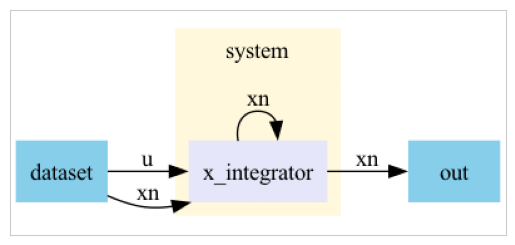

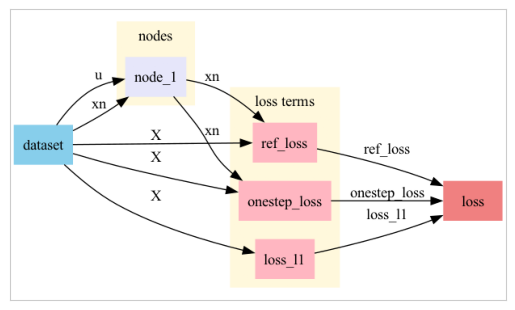

None


In [7]:

from neuromancer.system import Node, System
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer.problem import Problem
from neuromancer.dynamics import integrators


# One-element integrator for current state
integrator_x = integrators.RK4(sindy, h=ts)
integrator_node_x = Node(integrator_x, ['xn', 'u'], [f'xn'], name="x_integrator")
dynamics_model_x = System([integrator_node_x])
dynamics_model_x.show()

x = variable(f"X")
x_hat = variable(f'xn')[:, :-1, :]

# Define losses
onestep_loss_x = dyn_cfg["onestep_coef"] * ((x_hat[:, 1, :] == x[:, 1, :]) ^ 2)
onestep_loss_x.name = "onestep_loss"

reference_loss_x = dyn_cfg["ref_coef"] * ((x_hat == x) ^ 2)
reference_loss_x.name = "ref_loss"

# L1 sparsity regularization on model weights
l1_x = variable([x], lambda x: sum(torch.norm(p, p=1) for p in sindy.Xi))
loss_l1_x = dyn_cfg["l1_coef"] * (l1_x == 0)
loss_l1_x.name = "loss_l1"

# Assemble problem
objectives_x = [reference_loss_x, onestep_loss_x, loss_l1_x]
loss_x = PenaltyLoss(objectives_x, [])
problem_x = Problem([dynamics_model_x], loss_x)
problem_x.show()

lr = dyn_cfg["lr"]
optimizer_x = torch.optim.AdamW(problem_x.parameters(), lr=lr)

logger = CustomLogger(
    args=None,
    savedir='test',
    verbosity=200,
    stdout=['train_loss','dev_loss']
)




In [8]:

trainer_x = SparseTrainer(
    problem=problem_x,
    sindy=sindy,
    lr=lr,
    train_data=None,
    test_data=None,
    optimizers=optimizer_x,
    epochs=dyn_cfg["epochs"],
    train_metric='train_loss',
    eval_metric='dev_loss',
    logger=logger,
    device= device,
    threshold=dyn_cfg["threshold"],
    prune_every=dyn_cfg["prune_every"],
    warmup=300,
    patience=50,
    threshold_mult=dyn_cfg["threshold_mult"],
    prune_noise=dyn_cfg["prune_noise"],
    l1_decay=dyn_cfg["l1_decay"],
)

# Regenerate training data for updated horizon
trainer_x.train_data, trainer_x.dev_data = train_loader, dev_loader
trainer_x.problem = problem_x

# Train
best_model = trainer_x.train()
trainer_x.model.load_state_dict(best_model)


epoch: 0	train_loss: 8.739e-04	dev_loss: 4.030e-04	eltime:  0.11964
epoch: 200	train_loss: 1.316e-05	dev_loss: 1.001e-05	eltime:  7.32218
epoch: 400	train_loss: 6.239e-06	dev_loss: 4.490e-06	eltime:  14.38806
epoch: 600	train_loss: 3.694e-06	dev_loss: 2.764e-06	eltime:  21.57691
epoch: 800	train_loss: 2.581e-06	dev_loss: 2.049e-06	eltime:  28.98192
epoch: 1000	train_loss: 2.026e-06	dev_loss: 1.674e-06	eltime:  36.17839
epoch: 1200	train_loss: 1.687e-06	dev_loss: 1.426e-06	eltime:  43.31113
epoch: 1400	train_loss: 1.450e-06	dev_loss: 1.255e-06	eltime:  50.38403
epoch: 1600	train_loss: 1.298e-06	dev_loss: 1.152e-06	eltime:  57.53161
epoch: 1800	train_loss: 1.213e-06	dev_loss: 1.107e-06	eltime:  64.70199
epoch: 2000	train_loss: 1.153e-06	dev_loss: 1.074e-06	eltime:  71.88865
epoch: 2200	train_loss: 1.107e-06	dev_loss: 1.049e-06	eltime:  79.14647
epoch: 2400	train_loss: 1.077e-06	dev_loss: 1.034e-06	eltime:  86.34000
epoch: 2600	train_loss: 1.056e-06	dev_loss: 1.022e-06	eltime:  93.93523
e

<All keys matched successfully>

In [9]:
sindy.pretty_print()

dx0/dt = +7.9942e-02·u0 + -3.9976e-02·sqrt(x0) + -7.9905e-02·u0*u1
dx1/dt = +3.9981e-02·sqrt(x0) + -3.9980e-02·sqrt(x1) + +7.9943e-02·u0*u1


### 📈 Evaluate SINDy Model

Simulates and plots predicted vs. true trajectories using the learned full-state model.


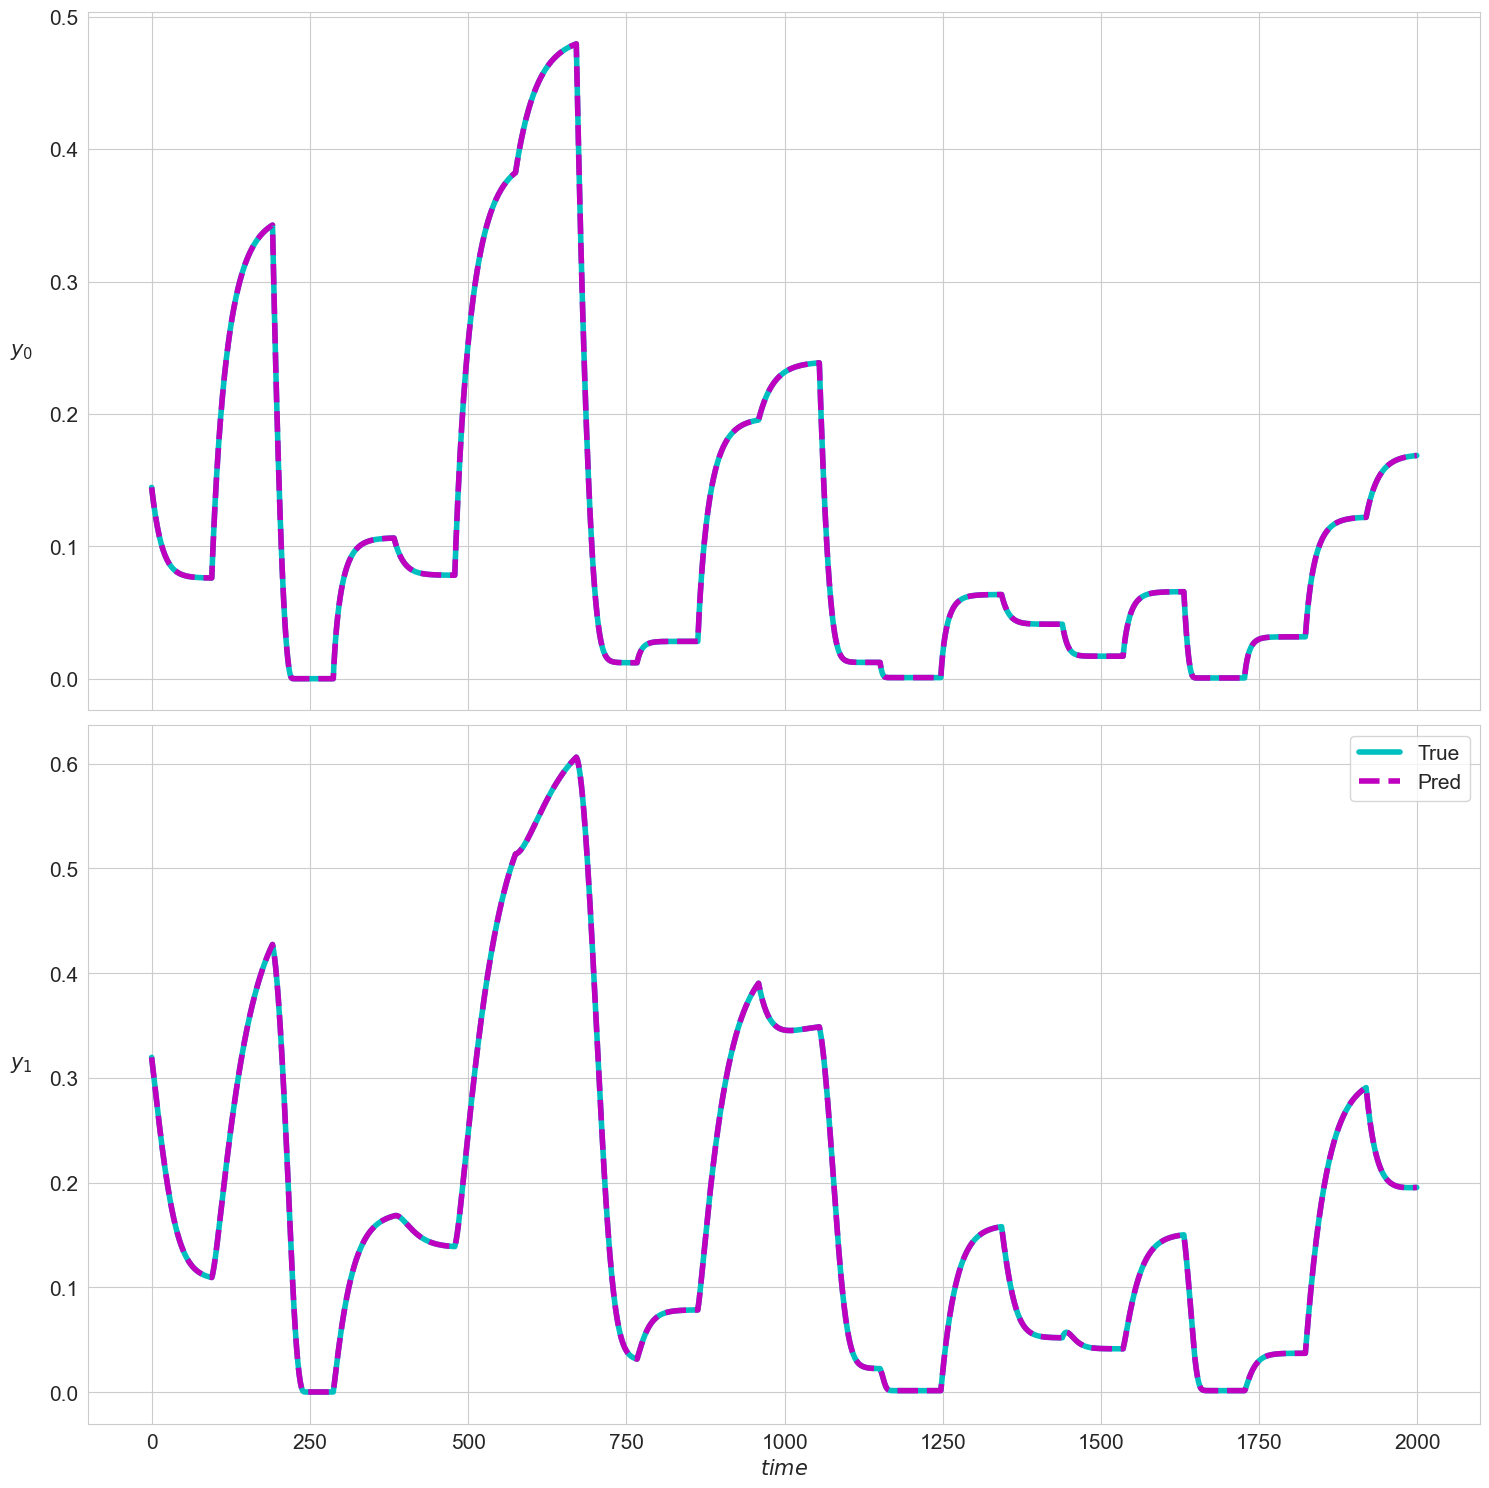

In [10]:
import matplotlib.pyplot as plt

# Create system for evaluation
sindy_system = System([integrator_node_x], nsteps=nsteps)
sindy_system.nsteps = test_data['X'].shape[1]

# Run simulation
test_output = sindy_system(test_data)

# Reshape for plotting
pred_traj = test_output['xn'][:, :-1, :].detach().numpy().reshape(-1, nx).T
true_traj = test_data['X'].detach().numpy().reshape(-1, nx).T

# Plot predicted vs. true trajectories
figsize = 15
fig, ax = plt.subplots(nx, figsize=(figsize, figsize))
labels = [f'$y_{k}$' for k in range(len(true_traj))]

for row, (t1, t2, label) in enumerate(zip(true_traj, pred_traj, labels)):
    axe = ax[row] if nx > 1 else ax
    axe.set_ylabel(label, rotation=0, labelpad=20, fontsize=figsize)
    axe.plot(t1, 'c', linewidth=4.0, label='True')
    axe.plot(t2, 'm--', linewidth=4.0, label='Pred')
    axe.tick_params(labelbottom=False, labelsize=figsize)

axe.tick_params(labelbottom=True, labelsize=figsize)
axe.legend(fontsize=figsize)
axe.set_xlabel('$time$', fontsize=figsize)
plt.tight_layout()


In [11]:
import json, torch
from pathlib import Path

sindy_lib_cfg = dict(
    n_features=lib.n_features,
    n_control=lib.n_control,
    include_bias=lib.include_bias,
    max_degree=lib.max_degree,
    add_sqrt=lib.add_sqrt,
    add_xu=lib.add_xu,
    add_u_prod=lib.add_u_prod,
    add_fourier=lib.add_fourier,
    max_freq=lib.max_freq,
    is_policy=lib.is_policy,
)

sindy_model_cfg = dict(
    n_out=sindy.n_out,
)

ckpt = {
    "lib_cfg": sindy_lib_cfg,
    "model_cfg": sindy_model_cfg,
    "active_idx": sindy.active_idx,          # list[list[int]]
    "state_dict": sindy.state_dict(),        # weights
}


# ---------------- user-supplied objects & constants ------------------------ #
base_dir       = "results/models/dynamics"
# --------------------------------------------------------------------------- #

run_id  = 1
while Path(base_dir, f"run_{run_id}").exists():
    run_id += 1
run_dir = Path(base_dir, f"run_{run_id}");  run_dir.mkdir(parents=True)
(Path(run_dir, "run_config.json")
 .write_text(json.dumps(dyn_cfg, indent=4)))

models_dir = run_dir / "saved_models"; models_dir.mkdir()
torch.save(ckpt, str(models_dir) + "/sindy.pt")   # you can call it .pkl if you want


## ⚙️ Training the Sparse Dictionary Policy


###  Load Policy Data

Loads the trainig data for control problem


In [12]:
from SparseDPC.data.getdata import get_policy_data
nsteps = 50  # prediction horizon
n_samples = 2000    # number of sampled scenarios
train_loader, dev_loader = get_policy_data(nsteps=nsteps,
                                           n_samples=n_samples,
                                           nx=nx,
                                           xmin=xmin,
                                           xmax=xmax,
                                           zero_refs=False,
                                           same_ref_for_all_states=True,
                                           device=device,
                                           batch_size=200,
                                           seed=5
                                           )

In [13]:
import importlib
import SparseDPC.vectorized.trainer

importlib.reload(SparseDPC.vectorized.trainer)
from SparseDPC.vectorized.trainer import SparsePolicyBuilder

In [14]:
import torch.nn as nn
from neuromancer.dynamics import ode
two_tank = ode.TwoTankParam()
two_tank.c1 = nn.Parameter(torch.tensor(gt_model.c1), requires_grad=False)
two_tank.c2 = nn.Parameter(torch.tensor(gt_model.c2), requires_grad=False)

import importlib
import SparseDPC.vectorized.trainer

importlib.reload(SparseDPC.vectorized.trainer)
from SparseDPC.vectorized.trainer import SparsePolicyBuilder

pol_configs = {
    "reg_coef": 20.0,
    "l1_coef": 0.01,
    "const_coef": 20.0,
    "Q_u": 0.0,
    "Q_du": 0.0,
    "Q_dx": 0.0,
    "lr": 0.005,
    "epochs": 4999,
    "threshold": 0.20,
    "prune_every": 600,
    "threshold_mult": 1.17,
    "prune_noise": 0.02,
    "prune_every_min": 300,
    "prune_every_decay": 50,
    "change_prune_every": True,
    "threshold_max" : 0.4,
    "lr_decay_gamma": 0.95,
    "lr_decay_step": 50,
    "l1_decay": 0.9999,
    "warmup": 100,
    "patience": 50
}
policies_seed = 0

policy_lib = CompiledFunctionLibrary(
    n_features=nx, n_control=1, is_policy=True,
    include_bias=False, max_degree=2,
    add_sqrt=True, add_xu=True, add_u_prod=True,
    add_fourier=True, max_freq=2
)

# create model (multi-output)
policy_sparse = SINDyVectorized(library=policy_lib, n_out=nu, policy_name=["u0","u1"], device=device, seed=policies_seed)
policy_sparse.pretty_print()

u0 = -3.7434e-04·x0 + +2.6822e-02·x1 + -4.1152e-02·r0 + -3.6797e-02·sqrt(x0) + -1.9258e-02·sqrt(x1) + +1.3408e-02·x0^2 + -9.9066e-04·x0*x1 + +3.9644e-02·x1^2 + -4.4372e-03·x0*r0 + +1.3231e-02·x1*r0 + -1.5111e-02·sin(1·x0) + -9.8283e-03·sin(2·x0) + -4.7767e-02·sin(1·x1) + -3.3114e-02·sin(2·x1) + -2.0611e-02·cos(1·x0) + +1.8522e-03·cos(2·x0) + +1.9767e-02·cos(1·x1) + +3.0001e-02·cos(2·x1) + -3.3897e-02·sin(1·r0) + -2.1773e-02·sin(2·r0) + +1.8161e-02·cos(1·r0) + +4.1519e-02·cos(2·r0)
u1 = -1.0290e-02·x0 + +3.7416e-02·x1 + -8.0592e-03·r0 + +5.2907e-03·sqrt(x0) + +4.5274e-02·sqrt(x1) + -4.6384e-02·x0^2 + -3.1477e-02·x0*x1 + -1.2658e-02·x1^2 + -1.9490e-02·x0*r0 + +4.3200e-02·x1*r0 + -3.2409e-02·sin(1·x0) + -2.3017e-02·sin(2·x0) + -3.4932e-02·sin(1·x1) + -4.6828e-02·sin(2·x1) + -2.9187e-02·cos(1·x0) + +4.2980e-02·cos(2·x0) + +2.2311e-02·cos(1·x1) + +2.4234e-02·cos(2·x1) + +2.6296e-03·sin(1·r0) + -2.5634e-02·sin(2·r0) + +8.4592e-03·cos(1·r0) + -4.6685e-02·cos(2·r0)


None


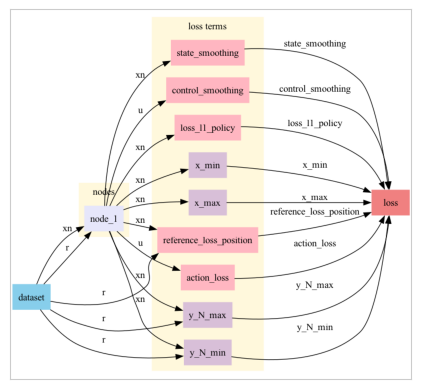

In [15]:
builder_SD_SINDy = SparsePolicyBuilder(
    dynamics_model= sindy,
    policy        = policy_sparse,
    is_sindy      = True,
    gt_model      = None,
    ts            = ts,
    nsteps        = nsteps,
    train_loader  = train_loader,
    dev_loader    = dev_loader,
    bounds        = dict(
                        xmin=xmin,
                        xmax=xmax,
                        umin=umin,
                        umax=umax
                    ),
    config        = pol_configs,
    device        = device,
    logger        = CustomLogger(args=None, savedir='runs', verbosity=10,
                                stdout=['dev_loss', 'train_loss'])
)

In [16]:
builder_SD_SINDy.policy.pretty_print()

u0 = -3.7434e-04·x0 + +2.6822e-02·x1 + -4.1152e-02·r0 + -3.6797e-02·sqrt(x0) + -1.9258e-02·sqrt(x1) + +1.3408e-02·x0^2 + -9.9066e-04·x0*x1 + +3.9644e-02·x1^2 + -4.4372e-03·x0*r0 + +1.3231e-02·x1*r0 + -1.5111e-02·sin(1·x0) + -9.8283e-03·sin(2·x0) + -4.7767e-02·sin(1·x1) + -3.3114e-02·sin(2·x1) + -2.0611e-02·cos(1·x0) + +1.8522e-03·cos(2·x0) + +1.9767e-02·cos(1·x1) + +3.0001e-02·cos(2·x1) + -3.3897e-02·sin(1·r0) + -2.1773e-02·sin(2·r0) + +1.8161e-02·cos(1·r0) + +4.1519e-02·cos(2·r0)
u1 = -1.0290e-02·x0 + +3.7416e-02·x1 + -8.0592e-03·r0 + +5.2907e-03·sqrt(x0) + +4.5274e-02·sqrt(x1) + -4.6384e-02·x0^2 + -3.1477e-02·x0*x1 + -1.2658e-02·x1^2 + -1.9490e-02·x0*r0 + +4.3200e-02·x1*r0 + -3.2409e-02·sin(1·x0) + -2.3017e-02·sin(2·x0) + -3.4932e-02·sin(1·x1) + -4.6828e-02·sin(2·x1) + -2.9187e-02·cos(1·x0) + +4.2980e-02·cos(2·x0) + +2.2311e-02·cos(1·x1) + +2.4234e-02·cos(2·x1) + +2.6296e-03·sin(1·r0) + -2.5634e-02·sin(2·r0) + +8.4592e-03·cos(1·r0) + -4.6685e-02·cos(2·r0)


In [17]:
builder_SD_SINDy.train()

/opt/anaconda3/envs/neuromancer/lib/python3.10/site-packages/neuromancer/constraint.py:172: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([200, 50, 2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(left, right)


epoch: 0	train_loss: 8.095e+00	dev_loss: 8.293e+00	eltime:  2.13601
epoch: 10	train_loss: 1.296e+00	dev_loss: 1.436e+00	eltime:  12.23191
epoch: 20	train_loss: 1.112e+00	dev_loss: 1.161e+00	eltime:  22.08404
epoch: 30	train_loss: 1.049e+00	dev_loss: 1.082e+00	eltime:  31.90960
epoch: 40	train_loss: 1.017e+00	dev_loss: 1.043e+00	eltime:  42.04850
epoch: 50	train_loss: 9.965e-01	dev_loss: 1.015e+00	eltime:  51.90917
epoch: 60	train_loss: 9.808e-01	dev_loss: 9.942e-01	eltime:  61.71241
epoch: 70	train_loss: 9.696e-01	dev_loss: 9.794e-01	eltime:  71.84886
epoch: 80	train_loss: 9.615e-01	dev_loss: 9.687e-01	eltime:  81.80814
epoch: 90	train_loss: 9.554e-01	dev_loss: 9.607e-01	eltime:  91.96801
epoch: 100	train_loss: 9.507e-01	dev_loss: 9.541e-01	eltime:  102.02680
epoch: 110	train_loss: 9.467e-01	dev_loss: 9.488e-01	eltime:  111.84377
epoch: 120	train_loss: 9.433e-01	dev_loss: 9.442e-01	eltime:  121.83228
epoch: 130	train_loss: 9.409e-01	dev_loss: 9.408e-01	eltime:  131.65088
epoch: 140	tra

In [18]:
# import copy
# from neuromancer.plot import pltCL, pltPhase
#
# # White-box ODE model (ground truth)
# two_tank = ode.TwoTankParam()
# two_tank.c1 = nn.Parameter(torch.tensor(gt_model.c1), requires_grad=False)
# two_tank.c2 = nn.Parameter(torch.tensor(gt_model.c2), requires_grad=False)
#
# # Euler integrator for ODE system
# gt_integrator = integrators.Euler(two_tank, h=torch.tensor(ts))
# gt_integrator_node = Node(gt_integrator, ['xn', 'u'], ['xn'], name='model')
#
# policy_node = Node(
#             lambda xn,r : torch.clamp(builder_SD_SINDy.policy(xn, r), umin, umax),
#             ['xn', 'r'], ['u'],
#             name="policy_combined"
#         )
# # Compose symbolic closed-loop system: policy + true plant
# gt_sindy_policy = copy.deepcopy(System([policy_node, gt_integrator_node]))
# gt_sindy_policy.show()
#
# # Closed-loop simulation setup
# nsteps_test = 1500
# torch.manual_seed(63)
# seed = 7
#
# rng = np.random.default_rng(seed)
#
# # Step reference signal (same across both states)
# np_refs = psl.signals.step(nsteps_test+1, 1, min=xmin, max=xmax, randsteps=5, rng=rng)
# R = torch.tensor(np_refs, dtype=torch.float32).reshape(1, nsteps_test+1, 1)
# torch_ref = torch.cat([R, R], dim=-1)
#
# # Random initial state
# x_sample = torch.rand(1, 1, nx, dtype=torch.float32)
# data = {
#     'xn': x_sample,
#     'x0_n': x_sample[:, :, 0:1],
#     'x1_n': x_sample[:, :, 1:2],
#     'r': torch_ref
# }
#
# # Simulate system
# gt_sindy_policy.nsteps = nsteps_test
# trajectories = gt_sindy_policy(data)
#
# # Constraint bounds for plotting
# Umin = umin * np.ones([nsteps_test, nu])
# Umax = umax * np.ones([nsteps_test, nu])
# Xmin = xmin * np.ones([nsteps_test+1, nx])
# Xmax = xmax * np.ones([nsteps_test+1, nx])
#
# # Plot trajectories
# pltCL(
#     Y=trajectories['xn'].detach().cpu().reshape(nsteps_test + 1, nx),
#     R=trajectories['r'].detach().cpu().reshape(nsteps_test + 1, nref),
#     U=trajectories['u'].detach().cpu().reshape(nsteps_test, nu),
#     Umin=Umin, Umax=Umax,
#     Ymin=Xmin, Ymax=Xmax
# )


In [19]:
builder_SD_SINDy.policy.pretty_print()

u0 = +1.1509e+00·cos(2·x0) + +1.6259e+00·cos(2·x1) + +4.4735e-01·sin(2·r0) + -2.7049e+00·cos(2·r0)
u1 = -9.9996e-01·cos(2·x0) + +1.0093e+00·cos(2·x1)


In [20]:
import json, torch
from pathlib import Path

policy_lib_cfg = dict(
    n_features=policy_lib.n_features,
    n_control=policy_lib.n_control,
    include_bias=policy_lib.include_bias,
    max_degree=policy_lib.max_degree,
    add_sqrt=policy_lib.add_sqrt,
    add_xu=policy_lib.add_xu,
    add_u_prod=policy_lib.add_u_prod,
    add_fourier=policy_lib.add_fourier,
    max_freq=policy_lib.max_freq,
    is_policy=policy_lib.is_policy,
)

policy_model_cfg = dict(
    n_out=policy_sparse.n_out,
    policy_name=policy_sparse.policy_name,
)

ckpt = {
    "lib_cfg": policy_lib_cfg,
    "model_cfg": policy_model_cfg,
    "active_idx": policy_sparse.active_idx,          # list[list[int]]
    "state_dict": policy_sparse.state_dict(),        # weights
}

builders       = {"SparseDPC": builder_SD_SINDy}   # tag → builder
base_dir       = "results/models/"
# 1. auto-increment parent run directory
run_id  = 1
while Path(base_dir, f"run_{run_id}").exists():
    run_id += 1
run_dir = Path(base_dir, f"run_{run_id}");  run_dir.mkdir(parents=True)
(Path(run_dir, "run_config.json")
 .write_text(json.dumps(pol_configs, indent=4)))

for tag, bld in builders.items():
    tag_dir    = run_dir / tag;          tag_dir.mkdir()
    models_dir = tag_dir / "saved_models"; models_dir.mkdir()
    torch.save(ckpt, str(models_dir) + "/policy_sparse.pt")   # you can call it .pkl if you want


None
neural policy(xn, r) -> u
Number of parameters: 1288


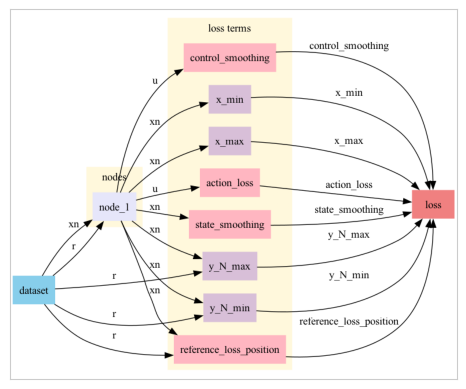

In [21]:
from neuromancer.modules import blocks
from neuromancer.modules.activations import activations
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer.problem import Problem
from neuromancer.trainer import Trainer
from neuromancer.dynamics import ode, integrators
from neuromancer.loggers import BasicLogger

nsteps=50


nn_config = {
    "layers": [32, 32],
    "reg_coef": 5.0,
    "const_coef": 20.0,
    "lr": 0.005,
    "epochs": 1000,
    "warmup": 1000,
    "patience": 400,
}

# neural net control policy with hard control action bounds
net_sindy = blocks.MLP_bounds(insize=nx + nref, outsize=nu, hsizes=nn_config["layers"],
                    nonlin=activations['gelu'], min=umin, max=umax)
policy_neural_sindy = Node(net_sindy, ['xn', 'r'], ['u'], name='neural policy')


builder_NN_SINDy = SparsePolicyBuilder(
    dynamics_model= sindy,
    policy        = policy_neural_sindy,
    is_sindy      = True,
    gt_model      = None,
    ts            = ts,
    nsteps        = nsteps,
    train_loader  = train_loader,
    dev_loader    = dev_loader,
    bounds        = dict(
                        xmin=xmin,
                        xmax=xmax,
                        umin=umin,
                        umax=umax
                    ),
    config        = pol_configs,
    device        = device,
    logger        = CustomLogger(args=None, savedir='runs', verbosity=10,
                                stdout=['dev_loss', 'train_loss'])
)

In [22]:
builder_NN_SINDy.train()

/opt/anaconda3/envs/neuromancer/lib/python3.10/site-packages/neuromancer/constraint.py:172: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([200, 50, 2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(left, right)


epoch: 0	train_loss: 8.929e+00	dev_loss: 9.060e+00	eltime:  1.91198
epoch: 10	train_loss: 1.087e+00	dev_loss: 1.143e+00	eltime:  10.86969
epoch: 20	train_loss: 9.095e-01	dev_loss: 9.362e-01	eltime:  19.71894
epoch: 30	train_loss: 8.740e-01	dev_loss: 8.676e-01	eltime:  28.79876
epoch: 40	train_loss: 8.438e-01	dev_loss: 8.409e-01	eltime:  37.66401
epoch: 50	train_loss: 8.283e-01	dev_loss: 8.251e-01	eltime:  46.51705
epoch: 60	train_loss: 8.204e-01	dev_loss: 8.165e-01	eltime:  55.32078
epoch: 70	train_loss: 8.139e-01	dev_loss: 8.072e-01	eltime:  64.49125
epoch: 80	train_loss: 8.095e-01	dev_loss: 8.022e-01	eltime:  73.36977
epoch: 90	train_loss: 8.065e-01	dev_loss: 7.990e-01	eltime:  82.27071
epoch: 100	train_loss: 8.046e-01	dev_loss: 7.971e-01	eltime:  91.17638
epoch: 110	train_loss: 8.145e-01	dev_loss: 7.991e-01	eltime:  100.37156
epoch: 120	train_loss: 8.024e-01	dev_loss: 7.952e-01	eltime:  109.21611
epoch: 130	train_loss: 8.067e-01	dev_loss: 7.958e-01	eltime:  118.21218
epoch: 140	trai

In [23]:
import json
import torch
from pathlib import Path

# tag → builder object (must contain .policy)
builders = {
    "NN-DPC": builder_NN_SINDy
}

base_dir = Path("results/models/")

# ---------------------------------------------------
# 1. auto-increment run directory
# ---------------------------------------------------
run_id = 1
while (base_dir / f"run_{run_id}").exists():
    run_id += 1

run_dir = base_dir / f"run_{run_id}"
run_dir.mkdir(parents=True, exist_ok=False)

# ---------------------------------------------------
# 2. Save each builder's models inside its tag folder
# ---------------------------------------------------
for tag, bld in builders.items():

    tag_dir = run_dir / tag
    tag_dir.mkdir(parents=True, exist_ok=False)

    # directory where the model will be saved
    models_dir = tag_dir / "saved_models"
    models_dir.mkdir(parents=True, exist_ok=False)

    # full save path
    save_path = models_dir / "policy_nn.pth"

    # save the policy weights
    torch.save(bld.policy.state_dict(), save_path)

    print(f"Saved {tag} policy → {save_path}")


Saved NN-DPC policy → results/models/run_2/NN-DPC/saved_models/policy_nn.pth


In [24]:
run_dir

PosixPath('results/models/run_2')